# 🏠 Project 1 — Predicting House Prices (Regression)

**The question:** given facts about a neighborhood (income, house age, rooms, location…),
can we predict its **median house price**?

This is called **regression** — the kind of machine learning where we predict a **number**
(as opposed to a *category* like "spam / not spam", which we'll do in Project 2).

We'll use the classic **California Housing** dataset that ships with scikit-learn.

> 📖 How to use this notebook: each step has a short explanation, then a code cell.
> Read the explanation → run the cell (Shift+Enter) → look at the output → move on.

## Step 0 — Import our tools

A quick tour of the libraries we'll lean on:
- **pandas** — holds data in tidy tables, like a spreadsheet you can code against.
- **matplotlib** — draws charts.
- **scikit-learn** — the machine-learning library; we grab only the few pieces we need.

In [1]:
# pandas: data in tables
import pandas as pd
# matplotlib: charts
import matplotlib.pyplot as plt

# scikit-learn pieces:
from sklearn.datasets import fetch_california_housing      # the dataset
from sklearn.model_selection import train_test_split       # splits data into train/test
from sklearn.linear_model import LinearRegression          # our model
from sklearn.metrics import mean_absolute_error, r2_score  # how we grade the model

print("Tools imported ✅")

Tools imported ✅


## Step 1 — Load the data and take a peek

The first time you run this, scikit-learn downloads the dataset once and caches it on your
computer, so future runs are instant.

We split the data into two parts:
- **features** — the input facts we get to look at (income, rooms, …).
- **target** — the single thing we're trying to predict (the house price).

In [2]:
# Load the dataset as a friendly pandas table.
housing_data = fetch_california_housing(as_frame=True)

# The input facts (one row per neighborhood):
house_features = housing_data.data      # ML books usually call this 'X'
# The thing we want to predict (median house value):
house_prices = housing_data.target      # ML books usually call this 'y'

print("Rows (neighborhoods):", house_features.shape[0])
print("Columns (facts per neighborhood):", house_features.shape[1])

Rows (neighborhoods): 20640
Columns (facts per neighborhood): 8


In [3]:
# .head() shows the first 5 rows so we can see what each column looks like.
house_features.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**What the columns mean:**

| Column | Meaning |
|--------|---------|
| `MedInc` | Median income in the neighborhood (in tens of thousands of $) |
| `HouseAge` | Median age of the houses |
| `AveRooms` | Average rooms per household |
| `AveBedrms` | Average bedrooms per household |
| `Population` | People living in the neighborhood |
| `AveOccup` | Average household size |
| `Latitude` / `Longitude` | Where it is on the map |

The **target** (`house_prices`) is the median house value, measured in units of **$100,000**.
So `2.5` means about **$250,000**.

In [4]:
# A peek at the prices we're trying to predict:
house_prices.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [5]:
# .describe() gives quick stats (average, min, max, …) for every feature column.
house_features.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


## Step 2 — Visualize the data

Before modeling, it helps to *see* the data. First, how are house prices spread out?

(bins=40: Controls how your data is divided. Matplotlib will automatically find the lowest and highest prices in house_prices, divide that entire range into exactly 40 equal-width buckets ("bins"), and count how many homes fit into each bucket)

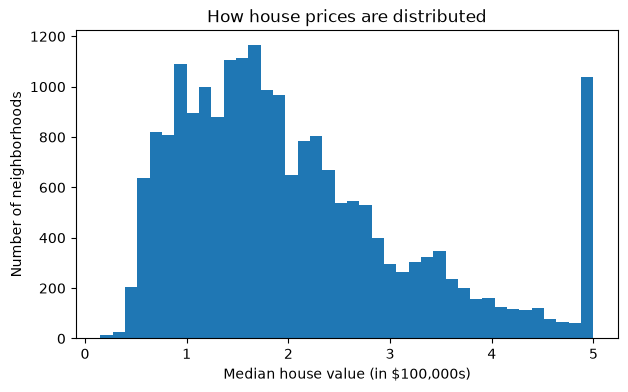

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(house_prices, bins=40)
plt.title("How house prices are distributed")
plt.xlabel("Median house value (in $100,000s)")
plt.ylabel("Number of neighborhoods")
plt.show()

Now a hunch: do **richer** neighborhoods have **pricier** houses? Let's plot income vs. price.

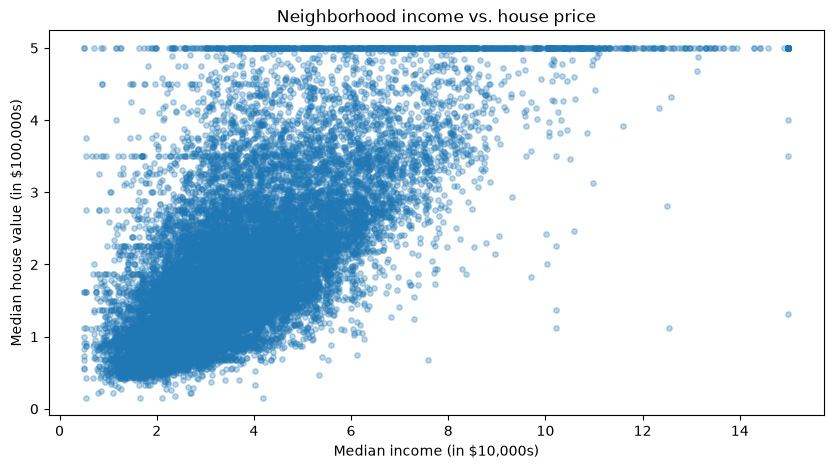

In [17]:
plt.figure(figsize=(10, 5))
plt.scatter(house_features["MedInc"], house_prices, s=15, alpha=0.3)
plt.title("Neighborhood income vs. house price")
plt.xlabel("Median income (in $10,000s)")
plt.ylabel("Median house value (in $100,000s)")
plt.show()

## Step 3 — Split into a training set and a test set

The golden rule of machine learning: **never grade a model on data it studied.**

So we hide 20% of the neighborhoods (the *test set*), train on the other 80% (the *training set*),
then later check how well the model does on the hidden 20%. It's like keeping practice exams
separate from the real exam.

- random_state acts as a seed for the random number generator. Setting this to a fixed number (like 42) ensures we get the exact same train/test split every time, making our model's results reproducible.

In [20]:
# test_size=0.2  -> keep 20% for testing
# random_state=42 -> makes the random shuffle reproducible (same split every run)
training_features, test_features, training_prices, test_prices = train_test_split(
    house_features, house_prices, test_size=0.2, random_state=42
)

print("Training neighborhoods:", training_features.shape[0])
print("Testing neighborhoods: ", test_features.shape[0])

Training neighborhoods: 16512
Testing neighborhoods:  4128


## Step 4 — Train the model

`LinearRegression` looks for the straight-line relationship between the features and the price.
The learning itself happens in one line: **`.fit()`**.

### Linear Regression Overview
Linear Regression predicts a continuous target variable (House Price) by finding the straight line that minimizes the distance between itself and all our data points. 

Essentially, it answers: **"For every additional square foot, how much does the price go up?"**

In [21]:
# Create the model...
price_model = LinearRegression()

# ...and let it learn from the TRAINING data only.
price_model.fit(training_features, training_prices)

print("Model trained ✅")

Model trained ✅


## Step 5 — Evaluate: how good is it?

We ask the model to predict prices for the **test** neighborhoods (which it never saw), then
compare its guesses to the real prices using two scores:
- **R²** — ranges up to 1.0 (perfect). 0.0 means "no better than always guessing the average".
- **MAE** (mean absolute error) — on average, how far off are we, in dollars?

In [23]:
# Predict prices for the unseen test neighborhoods:
predicted_prices = price_model.predict(test_features)

r2 = r2_score(test_prices, predicted_prices)
mae = mean_absolute_error(test_prices, predicted_prices)

print(f"R² score:            {r2:.2f}")
print(f"Average error (MAE): {mae:.2f}  (about ${mae * 100000:,.0f} per house)")

R² score:            0.58
Average error (MAE): 0.53  (about $53,320 per house)


A picture makes it click. Each dot is one neighborhood: its real price (x) vs. our prediction (y).
A perfect model would land every dot on the red diagonal.

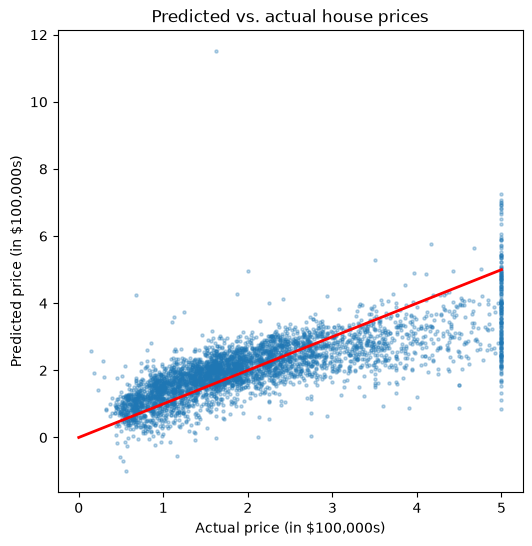

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(test_prices, predicted_prices, s=5, alpha=0.3)
plt.plot([0, 5], [0, 5], color="red", linewidth=2)  # the "perfect prediction" line
plt.title("Predicted vs. actual house prices")
plt.xlabel("Actual price (in $100,000s)")
plt.ylabel("Predicted price (in $100,000s)")
plt.show()

## Step 6 — Interpret what the model learned

A linear model assigns each feature a **weight**: positive pushes the price up, negative pushes it
down, and a bigger number means a stronger effect.

In [25]:
# Pair each feature with the weight the model gave it, sorted from most-negative to most-positive.
feature_effects = pd.Series(price_model.coef_, index=house_features.columns)
feature_effects.sort_values()

Longitude    -0.433708
Latitude     -0.419792
AveRooms     -0.123323
AveOccup     -0.003526
Population   -0.000002
HouseAge      0.009724
MedInc        0.448675
AveBedrms     0.783145
dtype: float64

Notice **`MedInc`** (income) usually has the biggest positive weight — richer neighborhoods,
pricier houses. That matches the scatter plot from Step 2. 🎯

## Step 7 — 🧪 Your turn

Small experiments to make this *yours* (change a cell, then re-run it and the cells below it):

1. In **Step 3**, change `test_size=0.2` to `0.3`. Does the R² score in Step 5 change much?
2. In **Step 2**, plot a different feature against price — try `"HouseAge"` instead of `"MedInc"`.
3. Look at Step 6: which feature has the **biggest positive** effect? Does that make intuitive sense?

Use the empty cell below as your scratchpad. There are no wrong answers — just explore.

In [13]:
# 🧪 Your experiments go here:
